In [25]:
import pandas as pd

ddd = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD.csv")

print(ddd.shape)
print(ddd.columns.tolist())

(4969, 37)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [5]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 8)]

click_cols = ['clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage',
              'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource',
              'clicks_subpage', 'clicks_url']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

ddd_sel = ddd[selected_cols].copy()
print(ddd_sel.shape)
ddd_sel.head()

(4969, 26)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_forumng,clicks_glossary,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouwiki,clicks_resource,clicks_subpage,clicks_url,final_result
0,M,South Region,HE Qualification,90-100%,55<=,0,60,N,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Withdrawn
1,M,London Region,HE Qualification,30-40%,55<=,0,90,N,93.0,83.0,...,36.0,0.0,184.0,12.0,64.0,18.0,70.0,227.0,23.0,Withdrawn
2,M,South West Region,Lower Than A Level,60-70%,0-35,0,60,N,48.0,58.0,...,142.0,0.0,99.0,5.0,55.0,36.0,45.0,20.0,7.0,Withdrawn
3,F,East Anglian Region,Lower Than A Level,30-40%,0-35,0,60,Y,75.0,73.0,...,142.0,0.0,259.0,2.0,64.0,38.0,41.0,231.0,33.0,Fail
4,F,Yorkshire Region,HE Qualification,10-20,35-55,0,70,N,58.0,57.0,...,92.0,0.0,162.0,0.0,100.0,75.0,32.0,175.0,15.0,Fail


In [7]:
print("imd_band unique values:")
print(ddd_sel['imd_band'].unique())
print()
print("imd_band NaN count:", ddd_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(ddd_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(ddd_sel[click_cols].isna().sum())

imd_band unique values:
['90-100%' '30-40%' '60-70%' '10-20' '80-90%' '0-10%' '40-50%' '50-60%'
 '20-30%' '70-80%' nan]

imd_band NaN count: 219

NaN counts - assessment scores:
ass_1_score    1136
ass_2_score    1558
ass_3_score    1800
ass_4_score    2104
ass_5_score    2433
ass_6_score    2765
ass_7_score    2527
dtype: int64

NaN counts - click columns:
clicks_externalquiz     438
clicks_forumng          438
clicks_glossary         438
clicks_homepage         438
clicks_oucollaborate    438
clicks_oucontent        438
clicks_ouwiki           438
clicks_resource         438
clicks_subpage          438
clicks_url              438
dtype: int64


In [9]:
# Fix imd_band missing % bug
ddd_sel['imd_band'] = ddd_sel['imd_band'].replace('10-20', '10-20%')

# Mode-fill imd_band NaN
imd_mode = ddd_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
ddd_sel['imd_band'] = ddd_sel['imd_band'].fillna(imd_mode)

print(ddd_sel['imd_band'].unique())

# Sanity check: all-or-nothing NaN pattern across clicks?
click_nan_mask = ddd_sel[click_cols].isna()
same_students = (click_nan_mask.sum(axis=1).isin([0, 10])).all()
print("All-or-nothing NaN pattern across clicks:", same_students)

# Impute
ddd_sel[assessment_cols] = ddd_sel[assessment_cols].fillna(-1)
ddd_sel[click_cols] = ddd_sel[click_cols].fillna(0)

print(ddd_sel.isna().sum().sum())

imd_band mode: 30-40%
['90-100%' '30-40%' '60-70%' '10-20%' '80-90%' '0-10%' '40-50%' '50-60%'
 '20-30%' '70-80%']
All-or-nothing NaN pattern across clicks: True
0


In [11]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
ddd_sel['final_result'] = ddd_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
ddd_sel['highest_education'] = ddd_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
ddd_sel['imd_band'] = ddd_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
ddd_sel['age_band'] = ddd_sel['age_band'].map(age_band_map)

ddd_sel['gender'] = ddd_sel['gender'].map({'M': 0, 'F': 1})
ddd_sel['disability'] = ddd_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ddd_sel['region'] = le.fit_transform(ddd_sel['region'])

print(ddd_sel.isna().sum().sum())
print(ddd_sel.dtypes)

0
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
ass_6_score             float64
ass_7_score             float64
clicks_externalquiz     float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_ouwiki           float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object


In [13]:
for col in click_cols:
    nonzero = (ddd_sel[col] != 0).sum()
    unique_vals = ddd_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_externalquiz: 3779 nonzero / 86 unique values
clicks_forumng: 4019 nonzero / 945 unique values
clicks_glossary: 1460 nonzero / 162 unique values
clicks_homepage: 4527 nonzero / 834 unique values
clicks_oucollaborate: 3073 nonzero / 133 unique values
clicks_oucontent: 4404 nonzero / 504 unique values
clicks_ouwiki: 2369 nonzero / 292 unique values
clicks_resource: 4302 nonzero / 261 unique values
clicks_subpage: 4407 nonzero / 655 unique values
clicks_url: 4003 nonzero / 173 unique values


In [15]:
ddd_sel['total_clicks'] = ddd_sel[click_cols].sum(axis=1)
ddd_sel = ddd_sel.drop(columns=click_cols)

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(ddd_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    ddd_sel[col] = binned.cat.codes

print()
print("Final shape:", ddd_sel.shape)
print(ddd_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 3 bins
ass_5_score: 3 bins
ass_6_score: 2 bins
ass_7_score: 2 bins
total_clicks: 4 bins

Final shape: (4969, 17)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'final_result', 'total_clicks']


In [17]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = ddd_sel.values.astype(float)
node_names = ddd_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_ddd = [f'ass_{i}_score' for i in range(1, 8)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_ddd + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1: course-time variables cannot cause demographics
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2: nothing can cause gender (pure root)
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3: assessments must respect sequential order
for i in range(1, 8):
    for j in range(1, 8):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4: course-time variables cannot cause studied_credits/num_of_prev_attempts
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5: final_result cannot cause any assessment score
for a in assessment_cols_ddd:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6: assessment scores cannot cause total_clicks
for a in assessment_cols_ddd:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7: final_result cannot cause total_clicks
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/17 [00:00<?, ?it/s]

PC complete.
Number of edges: 38


In [19]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> age_band
gender --> studied_credits
gender --> disability
gender --> total_clicks
highest_education --> region
imd_band --> region
disability --> region
age_band --> highest_education
highest_education --> disability
age_band --> total_clicks
num_of_prev_attempts --> total_clicks
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> ass_5_score
ass_1_score --> ass_7_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_5_score
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_5_score
ass_3_score --> ass_7_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_6_score
ass_4_score --> ass_7_score
ass_4_score --> final_result
total_clicks --> ass_4_score
ass_5_score --> ass_6_score
ass_5_score --> final_result
total_clicks --> ass_5_score
ass_6_score --> final_resul

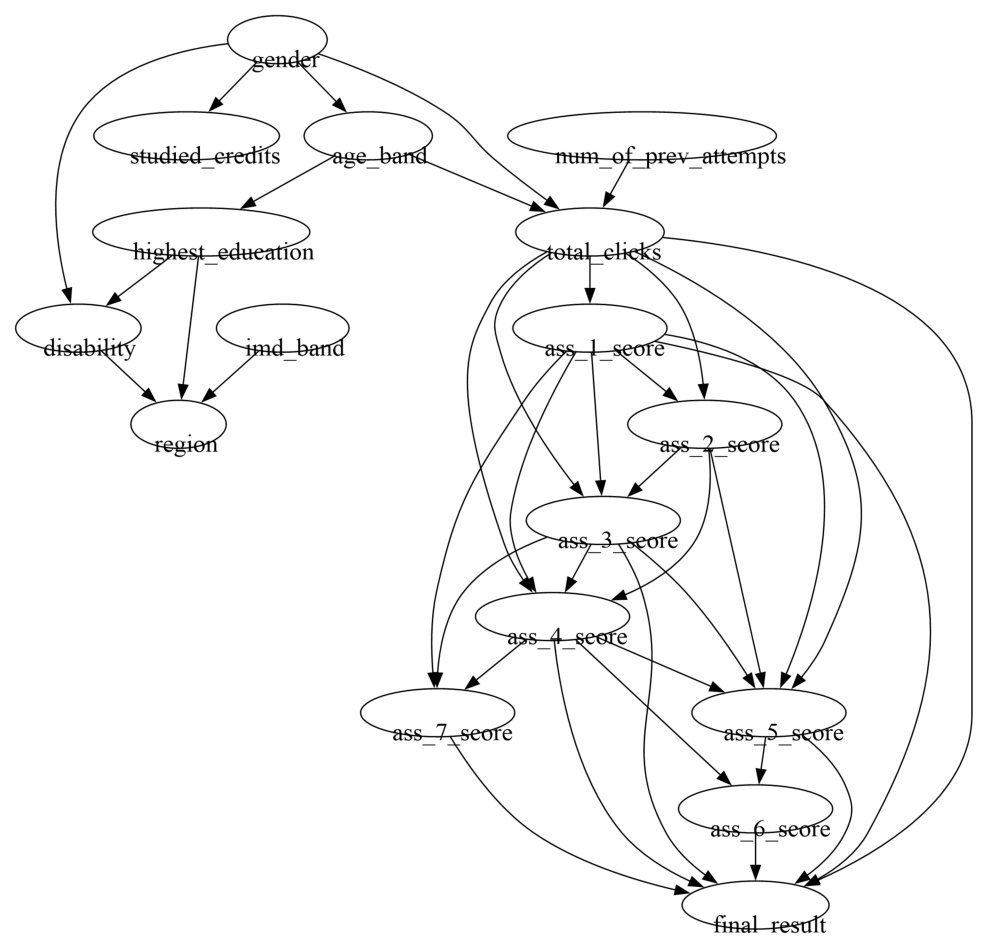

In [21]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

# domain specific DAGs

## Student info vs final_result

In [30]:
df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD.csv")

print(df.shape)
print(list(df.columns))

(4969, 37)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [32]:
print(df[['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']].dtypes)
print(df[['gender', 'highest_education', 'final_result']].head(3))

gender               object
region               object
highest_education    object
imd_band             object
age_band             object
disability           object
final_result         object
dtype: object
  gender   highest_education final_result
0      M    HE Qualification    Withdrawn
1      M    HE Qualification    Withdrawn
2      M  Lower Than A Level    Withdrawn


In [34]:
final_result_map = {'Withdrawn':0,'Fail':1,'Pass':2,'Distinction':3}
education_map = {'No Formal quals':0,'Lower Than A Level':1,'A Level or Equivalent':2,
                  'HE Qualification':3,'Post Graduate Qualification':4}
age_band_map = {'0-35':0,'35-55':1,'55<=':2}

print(df['imd_band'].unique())

df['final_result'] = df['final_result'].map(final_result_map)
df['highest_education'] = df['highest_education'].map(education_map)
df['age_band'] = df['age_band'].map(age_band_map)
df['gender'] = df['gender'].map({'M':0,'F':1})
df['disability'] = df['disability'].map({'N':0,'Y':1})
df['region'] = df['region'].astype('category').cat.codes

print(df[['gender', 'highest_education', 'age_band', 'final_result']].isnull().sum())

['90-100%' '30-40%' '60-70%' '10-20' '80-90%' '0-10%' '40-50%' '50-60%'
 '20-30%' '70-80%' nan]
gender               0
highest_education    0
age_band             0
final_result         0
dtype: int64


In [36]:
imd_map = {'0-10%':0,'10-20%':1,'10-20':1,'20-30%':2,'30-40%':3,'40-50%':4,
           '50-60%':5,'60-70%':6,'70-80%':7,'80-90%':8,'90-100%':9}

df['imd_band'] = df['imd_band'].map(imd_map)

print("NaN before mode-fill:", df['imd_band'].isnull().sum())

imd_mode = df['imd_band'].mode()[0]
df['imd_band'] = df['imd_band'].fillna(imd_mode)

print("NaN after mode-fill:", df['imd_band'].isnull().sum())
print("Mode used:", imd_mode)

NaN before mode-fill: 219
NaN after mode-fill: 0
Mode used: 3.0


In [38]:
demo_cols_ddd = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                  'num_of_prev_attempts', 'studied_credits', 'disability']

dag1_data_ddd = df[demo_cols_ddd + ['final_result']].copy()

print(dag1_data_ddd.shape)
print(dag1_data_ddd.isnull().sum())

(4969, 9)
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [40]:
node_names_dag1_ddd = list(dag1_data_ddd.columns)
nodes_dag1_ddd = [GraphNode(name) for name in node_names_dag1_ddd]

bk1_ddd = BackgroundKnowledge()

gender_node_ddd = nodes_dag1_ddd[node_names_dag1_ddd.index('gender')]
final_result_node_ddd = nodes_dag1_ddd[node_names_dag1_ddd.index('final_result')]

# Rule 2: nothing causes gender (root)
for n in nodes_dag1_ddd:
    if n != gender_node_ddd:
        bk1_ddd.add_forbidden_by_node(n, gender_node_ddd)

# Rule 1 (generalized): final_result cannot cause any demographic
for n in nodes_dag1_ddd:
    if n != final_result_node_ddd:
        bk1_ddd.add_forbidden_by_node(final_result_node_ddd, n)

# Sanity check
highest_education_node_ddd = nodes_dag1_ddd[node_names_dag1_ddd.index('highest_education')]
print("highest_education -> gender forbidden:", bk1_ddd.is_forbidden(highest_education_node_ddd, gender_node_ddd))
print("final_result -> studied_credits forbidden:", bk1_ddd.is_forbidden(final_result_node_ddd, nodes_dag1_ddd[node_names_dag1_ddd.index('studied_credits')]))

highest_education -> gender forbidden: True
final_result -> studied_credits forbidden: True


In [42]:
data1_ddd = dag1_data_ddd.to_numpy()

cg1_ddd = pc(data1_ddd, alpha=0.05, indep_test='gsq', background_knowledge=bk1_ddd, node_names=node_names_dag1_ddd)

print("Number of edges:", cg1_ddd.G.get_num_edges())

  0%|          | 0/9 [00:00<?, ?it/s]

Number of edges: 13


In [44]:
for edge in cg1_ddd.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

gender [TAIL] -- [ARROW] age_band
gender [TAIL] -- [ARROW] studied_credits
gender [TAIL] -- [ARROW] disability
highest_education [TAIL] -- [ARROW] region
imd_band [TAIL] -- [ARROW] region
disability [TAIL] -- [ARROW] region
age_band [TAIL] -- [ARROW] highest_education
highest_education [TAIL] -- [ARROW] disability
highest_education [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [ARROW] final_result
num_of_prev_attempts [TAIL] -- [ARROW] disability
num_of_prev_attempts [TAIL] -- [ARROW] final_result
disability [TAIL] -- [ARROW] final_result


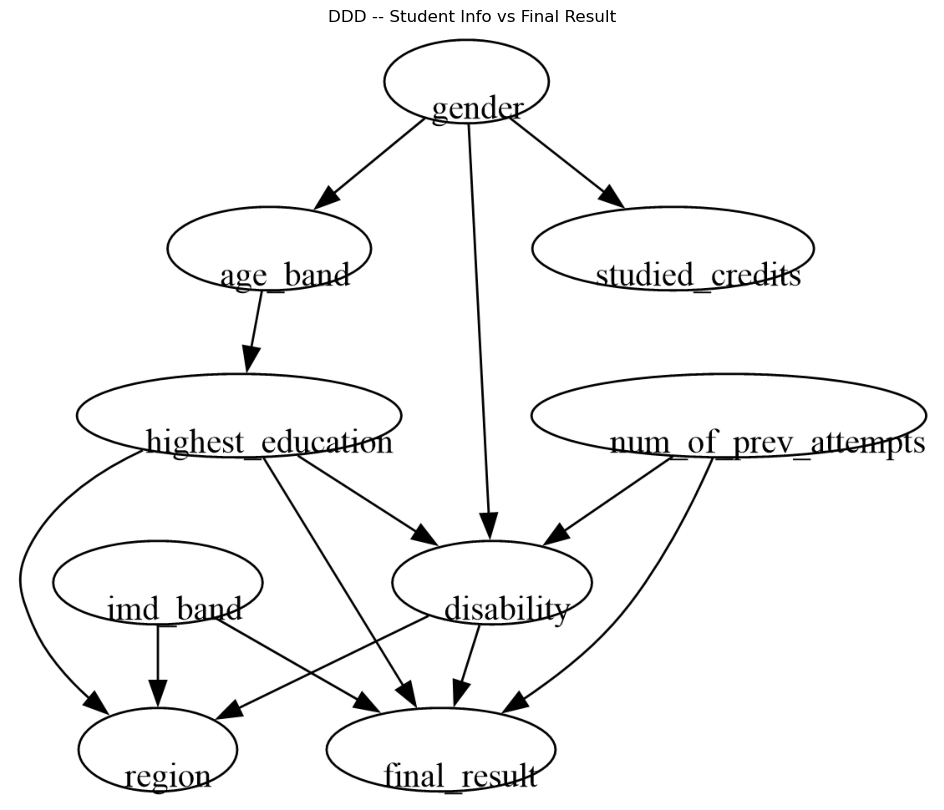

In [46]:
pyd1_ddd = GraphUtils.to_pydot(cg1_ddd.G, labels=node_names_dag1_ddd)

for node in pyd1_ddd.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes1_ddd = pyd1_ddd.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD_DAG1_studentinfo_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_ddd)

img1_ddd = mpimg.imread(io.BytesIO(png_bytes1_ddd), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_ddd)
plt.axis('off')
plt.title("DDD -- Student Info vs Final Result")
plt.show()

## assessments vs final_result

In [49]:
ass_cols_ddd = [f'ass_{i}_score' for i in range(1, 8)]

df[ass_cols_ddd] = df[ass_cols_ddd].fillna(-1)

dag2_data_ddd = df[ass_cols_ddd + ['final_result']].copy()

for col in ass_cols_ddd:
    dag2_data_ddd[col] = pd.qcut(dag2_data_ddd[col], q=4, labels=False, duplicates='drop')

print(dag2_data_ddd.shape)
print(dag2_data_ddd.nunique())

(4969, 8)
ass_1_score     4
ass_2_score     3
ass_3_score     3
ass_4_score     3
ass_5_score     3
ass_6_score     2
ass_7_score     2
final_result    4
dtype: int64


In [51]:
node_names_dag2_ddd = list(dag2_data_ddd.columns)
nodes_dag2_ddd = [GraphNode(name) for name in node_names_dag2_ddd]

bk2_ddd = BackgroundKnowledge()

final_result_node2_ddd = nodes_dag2_ddd[node_names_dag2_ddd.index('final_result')]

# Rule 5: final_result cannot cause any assessment
for n in nodes_dag2_ddd:
    if n != final_result_node2_ddd:
        bk2_ddd.add_forbidden_by_node(final_result_node2_ddd, n)

# Rule 3: sequential order -- ass_j cannot cause ass_i if j > i
for j in range(1, 8):
    for i in range(1, j):
        node_j = nodes_dag2_ddd[node_names_dag2_ddd.index(f'ass_{j}_score')]
        node_i = nodes_dag2_ddd[node_names_dag2_ddd.index(f'ass_{i}_score')]
        bk2_ddd.add_forbidden_by_node(node_j, node_i)

# Sanity check
ass1_node_ddd = nodes_dag2_ddd[node_names_dag2_ddd.index('ass_1_score')]
ass5_node_ddd = nodes_dag2_ddd[node_names_dag2_ddd.index('ass_5_score')]
print("ass_5 -> ass_1 forbidden:", bk2_ddd.is_forbidden(ass5_node_ddd, ass1_node_ddd))
print("final_result -> ass_1 forbidden:", bk2_ddd.is_forbidden(final_result_node2_ddd, ass1_node_ddd))

ass_5 -> ass_1 forbidden: True
final_result -> ass_1 forbidden: True


In [53]:
data2_ddd = dag2_data_ddd.to_numpy()

cg2_ddd = pc(data2_ddd, alpha=0.05, indep_test='gsq', background_knowledge=bk2_ddd, node_names=node_names_dag2_ddd)

print("Number of edges:", cg2_ddd.G.get_num_edges())

  0%|          | 0/8 [00:00<?, ?it/s]

Number of edges: 21


In [55]:
for edge in cg2_ddd.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

ass_1_score [TAIL] -- [ARROW] ass_2_score
ass_1_score [TAIL] -- [ARROW] ass_3_score
ass_1_score [TAIL] -- [ARROW] ass_4_score
ass_1_score [TAIL] -- [ARROW] ass_5_score
ass_1_score [TAIL] -- [ARROW] ass_7_score
ass_1_score [TAIL] -- [ARROW] final_result
ass_2_score [TAIL] -- [ARROW] ass_3_score
ass_2_score [TAIL] -- [ARROW] ass_4_score
ass_2_score [TAIL] -- [ARROW] ass_5_score
ass_3_score [TAIL] -- [ARROW] ass_4_score
ass_3_score [TAIL] -- [ARROW] ass_5_score
ass_3_score [TAIL] -- [ARROW] ass_7_score
ass_3_score [TAIL] -- [ARROW] final_result
ass_4_score [TAIL] -- [ARROW] ass_5_score
ass_4_score [TAIL] -- [ARROW] ass_6_score
ass_4_score [TAIL] -- [ARROW] ass_7_score
ass_4_score [TAIL] -- [ARROW] final_result
ass_5_score [TAIL] -- [ARROW] ass_6_score
ass_5_score [TAIL] -- [ARROW] final_result
ass_6_score [TAIL] -- [ARROW] final_result
ass_7_score [TAIL] -- [ARROW] final_result


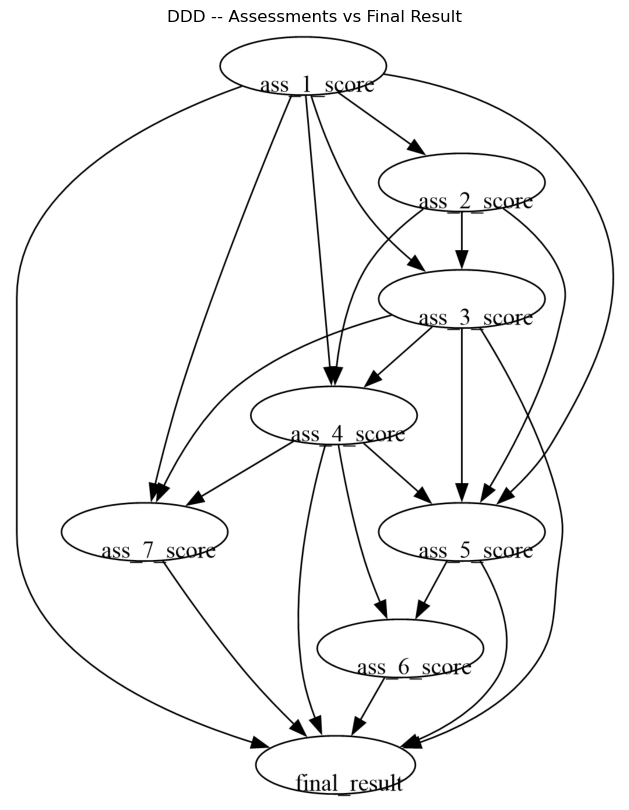

In [57]:
pyd2_ddd = GraphUtils.to_pydot(cg2_ddd.G, labels=node_names_dag2_ddd)

for node in pyd2_ddd.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes2_ddd = pyd2_ddd.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD_DAG2_assessments_vs_finalresult.png", "wb") as f:
    f.write(png_bytes2_ddd)

img2_ddd = mpimg.imread(io.BytesIO(png_bytes2_ddd), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img2_ddd)
plt.axis('off')
plt.title("DDD -- Assessments vs Final Result")
plt.show()

## Individual Clicks vs Final Result

In [59]:
raw_click_cols_ddd = ['clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage',
                       'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource',
                       'clicks_subpage', 'clicks_url']

clicks_raw_ddd = df[raw_click_cols_ddd].fillna(0)

for col in raw_click_cols_ddd:
    print(col, "nonzero:", (clicks_raw_ddd[col] > 0).sum(), "unique:", clicks_raw_ddd[col].nunique())

clicks_externalquiz nonzero: 3779 unique: 86
clicks_forumng nonzero: 4019 unique: 945
clicks_glossary nonzero: 1460 unique: 162
clicks_homepage nonzero: 4527 unique: 834
clicks_oucollaborate nonzero: 3073 unique: 133
clicks_oucontent nonzero: 4404 unique: 504
clicks_ouwiki nonzero: 2369 unique: 292
clicks_resource nonzero: 4302 unique: 261
clicks_subpage nonzero: 4407 unique: 655
clicks_url nonzero: 4003 unique: 173


In [61]:
dag3_data_ddd = clicks_raw_ddd.copy()

for col in raw_click_cols_ddd:
    dag3_data_ddd[col] = pd.qcut(dag3_data_ddd[col], q=4, labels=False, duplicates='drop')

dag3_data_ddd['final_result'] = df['final_result'].values

print(dag3_data_ddd.shape)
for col in dag3_data_ddd.columns:
    print(col, dag3_data_ddd[col].nunique())

(4969, 11)
clicks_externalquiz 4
clicks_forumng 4
clicks_glossary 2
clicks_homepage 4
clicks_oucollaborate 3
clicks_oucontent 4
clicks_ouwiki 2
clicks_resource 4
clicks_subpage 4
clicks_url 4
final_result 4


In [63]:
node_names_dag3_ddd = list(dag3_data_ddd.columns)
nodes_dag3_ddd = [GraphNode(name) for name in node_names_dag3_ddd]

bk3_ddd = BackgroundKnowledge()

final_result_node3_ddd = nodes_dag3_ddd[node_names_dag3_ddd.index('final_result')]

# Rule 6 (per-column): final_result cannot cause any individual click variable
for n in nodes_dag3_ddd:
    if n != final_result_node3_ddd:
        bk3_ddd.add_forbidden_by_node(final_result_node3_ddd, n)

# Sanity check
clicks_resource_node_ddd = nodes_dag3_ddd[node_names_dag3_ddd.index('clicks_resource')]
print("final_result -> clicks_resource forbidden:", bk3_ddd.is_forbidden(final_result_node3_ddd, clicks_resource_node_ddd))

final_result -> clicks_resource forbidden: True


In [65]:
data3_ddd = dag3_data_ddd.to_numpy()

cg3_ddd = pc(data3_ddd, alpha=0.05, indep_test='gsq', background_knowledge=bk3_ddd, node_names=node_names_dag3_ddd)

print("Number of edges:", cg3_ddd.G.get_num_edges())

  0%|          | 0/11 [00:00<?, ?it/s]

Number of edges: 35


In [67]:
for edge in cg3_ddd.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

clicks_externalquiz [TAIL] -- [ARROW] clicks_homepage
clicks_oucollaborate [TAIL] -- [ARROW] clicks_externalquiz
clicks_externalquiz [TAIL] -- [ARROW] clicks_resource
clicks_subpage [TAIL] -- [ARROW] clicks_externalquiz
clicks_externalquiz [TAIL] -- [ARROW] clicks_url
clicks_externalquiz [TAIL] -- [ARROW] final_result
clicks_homepage [TAIL] -- [ARROW] clicks_forumng
clicks_oucollaborate [TAIL] -- [ARROW] clicks_forumng
clicks_oucontent [TAIL] -- [ARROW] clicks_forumng
clicks_ouwiki [TAIL] -- [ARROW] clicks_forumng
clicks_subpage [TAIL] -- [ARROW] clicks_forumng
clicks_url [TAIL] -- [ARROW] clicks_forumng
clicks_glossary [TAIL] -- [ARROW] clicks_ouwiki
clicks_glossary [TAIL] -- [TAIL] clicks_resource
clicks_oucollaborate [TAIL] -- [ARROW] clicks_homepage
clicks_oucontent [TAIL] -- [ARROW] clicks_homepage
clicks_ouwiki [TAIL] -- [ARROW] clicks_homepage
clicks_homepage [TAIL] -- [ARROW] clicks_resource
clicks_subpage [TAIL] -- [ARROW] clicks_homepage
clicks_url [TAIL] -- [ARROW] clicks_ho

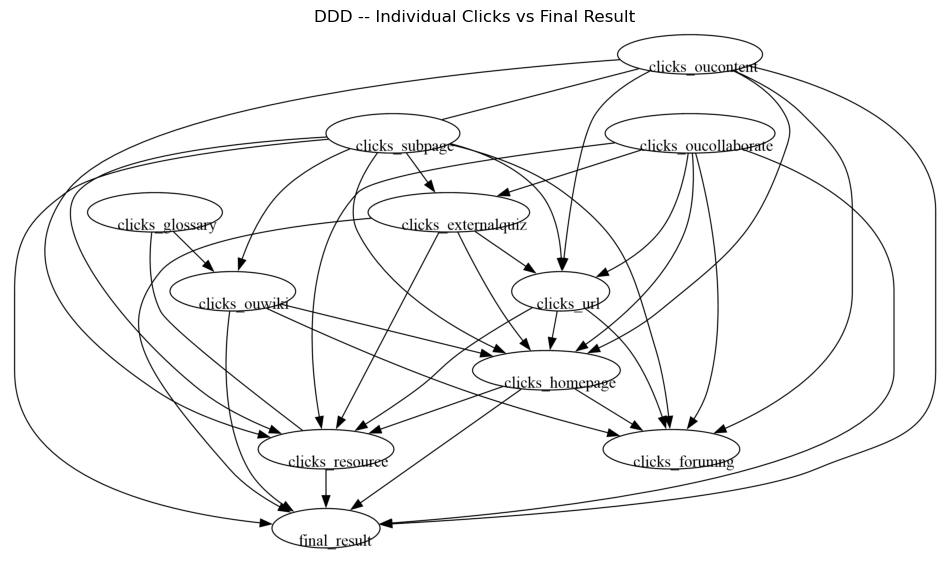

In [69]:
pyd3_ddd = GraphUtils.to_pydot(cg3_ddd.G, labels=node_names_dag3_ddd)

for node in pyd3_ddd.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes3_ddd = pyd3_ddd.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD_DAG3_clicks_vs_finalresult.png", "wb") as f:
    f.write(png_bytes3_ddd)

img3_ddd = mpimg.imread(io.BytesIO(png_bytes3_ddd), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img3_ddd)
plt.axis('off')
plt.title("DDD -- Individual Clicks vs Final Result")
plt.show()